# Strategic Humanitarian Aid Allocation (HELP International)

This notebook implements **Task 2 (EDA)** and **Task 3 (preprocessing for K-Means)** for the HELP International dataset.

- **Task 2:** statistical summary, outlier visualization, and correlation analysis
- **Task 3:** IQR-based outlier handling + feature standardization for clustering


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(context="notebook", style="whitegrid")


## Load and Prepare Data

To keep the workflow reproducible, we start from the **raw** dataset file (`Country-data.csv`) rather than relying on an intermediate CSV created by another notebook.

The dataset includes percent-based indicators for trade and health (`exports`, `health`, `imports`). For this project, Task 1's **percent-to-absolute** conversion is reproduced here only because these transformed values are required before EDA and feature standardization for K-Means.

Importantly, this notebook **does not write** any cleaned intermediate file to disk.

In [18]:
from pathlib import Path

# ----------------------------
# Flags
# ----------------------------
PLOT_LOG_BOXPLOTS = True
SAVE_OUTPUTS = False

# ----------------------------
# Paths and required columns
# ----------------------------
project_dir = Path.cwd()
country_csv_path = project_dir / "Country-data.csv"

if not country_csv_path.exists():
    raise FileNotFoundError(
        f"Could not find {country_csv_path}. Run the notebook from the project folder."
    )

country_col = "country"
feature_cols = [
    "child_mort",
    "exports",
    "health",
    "imports",
    "income",
    "inflation",
    "life_expec",
    "total_fer",
    "gdpp",
]

required_cols = [country_col] + feature_cols

# ----------------------------
# Load raw data
# ----------------------------
df = pd.read_csv(country_csv_path)

# ----------------------------
# Task 1 feature transformations (in-memory only)
# ----------------------------
# exports, health, imports are percent values. Convert to absolute per-capita values
# using the same rule as Task 1:
#   exports = exports * gdpp / 100
#   health  = health  * gdpp / 100
#   imports = imports * gdpp / 100
df_prepared = df.copy()

for col in ["exports", "health", "imports"]:
    if col not in df_prepared.columns:
        raise KeyError(f"Expected column '{col}' not found in the dataset.")

df_prepared["exports"] = df_prepared["exports"] * df_prepared["gdpp"] / 100.0
df_prepared["health"] = df_prepared["health"] * df_prepared["gdpp"] / 100.0
df_prepared["imports"] = df_prepared["imports"] * df_prepared["gdpp"] / 100.0


In [19]:
# ----------------------------
# Validation checks
# ----------------------------
missing_required = [c for c in required_cols if c not in df_prepared.columns]
if missing_required:
    raise KeyError(f"Missing expected columns: {missing_required}")

# Convert feature columns to numeric (raises if conversion fails)
df_prepared[feature_cols] = df_prepared[feature_cols].apply(pd.to_numeric, errors="raise")

if df_prepared[required_cols].isna().any().any():
    missing_counts = df_prepared[required_cols].isna().sum()
    missing_counts = missing_counts[missing_counts > 0]
    raise ValueError(
        "Dataset contains missing values in required columns:\n" + missing_counts.to_string()
    )

# Identify numeric columns robustly
numeric_columns = df_prepared.select_dtypes(include=[np.number]).columns.tolist()
missing_numeric = [c for c in feature_cols if c not in numeric_columns]
if missing_numeric:
    raise TypeError(f"These expected feature columns are not numeric: {missing_numeric}")

# Concise dataset summary
print("Dataset shape:", df_prepared.shape)
print("Dtypes (required cols):")
print(df_prepared[required_cols].dtypes)
print("\nNumeric features used for EDA/Scaling:", feature_cols)


Dataset shape: (167, 10)
Dtypes (required cols):
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Numeric features used for EDA/Scaling: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## Exploratory Data Analysis

We summarize the dataset with mean, median, and standard deviation, and we also compute the **coefficient of variation (CV)** to compare relative variability across indicators.

Next, we use the **IQR rule** to count outliers and visualize distributions using boxplots. For monetary-scale features, we include optional `log1p` boxplots to improve readability when distributions are strongly skewed.

Finally, we use a correlation heatmap to understand relationships among variables, which is helpful when interpreting potential cluster structure.

In [20]:
# Summary statistics for EDA (Task 2)
summary_stats = df_prepared[feature_cols].agg(["mean", "median", "std"]).T
summary_stats["cv"] = summary_stats["std"] / summary_stats["mean"].replace(0, np.nan)
summary_stats = summary_stats[["mean", "median", "std", "cv"]].round(4)

summary_stats


,mean,median,std,cv
child_mort,38.2701,19.300,40.3289,1.0538
exports,7420.6188,1777.440,17973.8858,2.4222
health,1056.7332,321.886,1801.4089,1.7047
imports,6588.3521,2045.580,14710.8104,2.2329
income,17144.6886,9960.000,19278.0677,1.1244
inflation,7.7818,5.390,10.5707,1.3584
life_expec,70.5557,73.100,8.8932,0.1260
total_fer,2.9480,2.410,1.5138,0.5135
gdpp,12964.1557,4660.000,18328.7048,1.4138


## Outlier Review and Handling

We use the standard **IQR-based** outlier rule for each numeric feature.

- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 * IQR
- Upper bound = Q3 + 1.5 * IQR

We first count outliers (EDA step). Later (Task 3), we reuse the same bounds for **winsorization/capping** before scaling.

In [21]:
def compute_iqr_bounds(data: pd.DataFrame, cols: list[str]):
    """Compute IQR lower/upper bounds for each column."""
    bounds = {}
    for col in cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        bounds[col] = (lower, upper)
    return bounds

def count_iqr_outliers(data: pd.DataFrame, cols: list[str], bounds: dict):
    counts = {}
    for col in cols:
        lower, upper = bounds[col]
        counts[col] = ((data[col] < lower) | (data[col] > upper)).sum()
    return pd.Series(counts).sort_values(ascending=False)

# Compute and reuse bounds later in Task 3
iqr_bounds = compute_iqr_bounds(df_prepared, feature_cols)
iqr_outlier_counts = count_iqr_outliers(df_prepared, feature_cols, iqr_bounds)

iqr_outlier_counts


gdpp          25
health        24
exports       18
imports       12
income         8
inflation      5
child_mort     4
life_expec     3
total_fer      1
dtype: int64

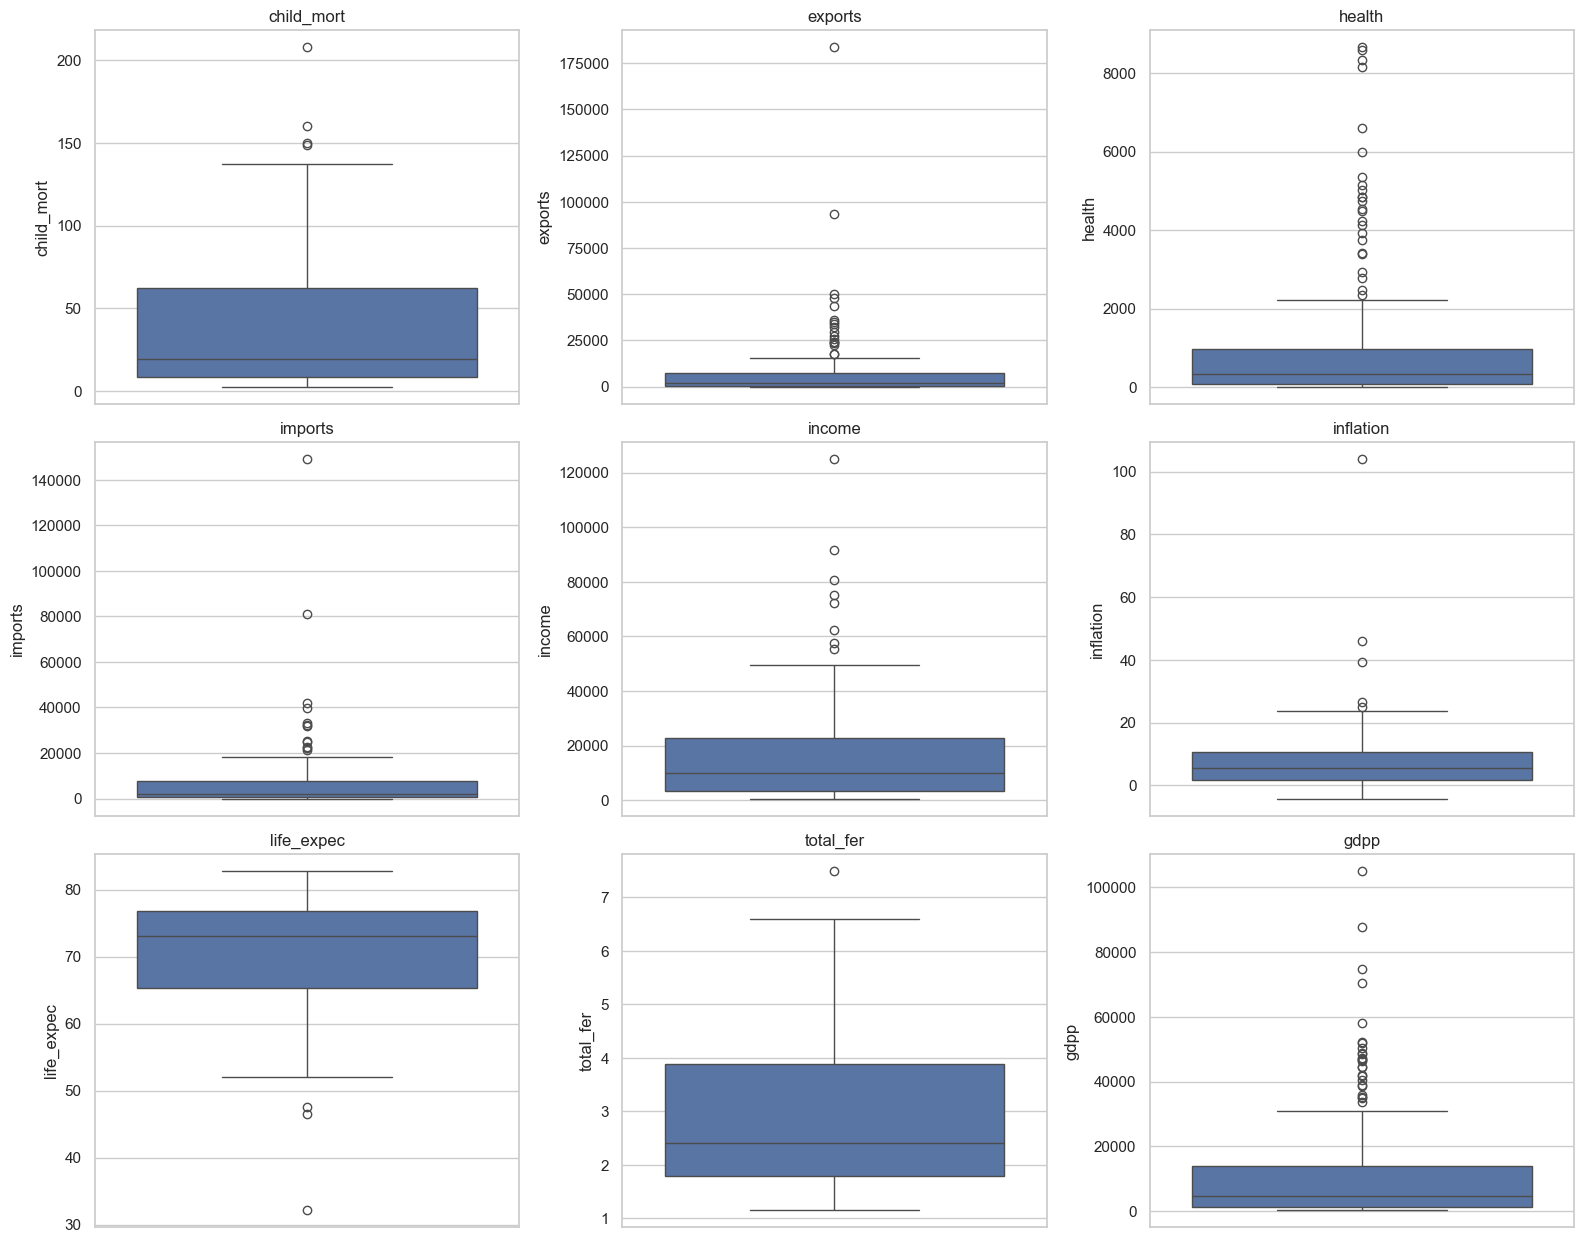

In [22]:
# Boxplots for all numeric features
n_features = len(feature_cols)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.2 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(y=df_prepared[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


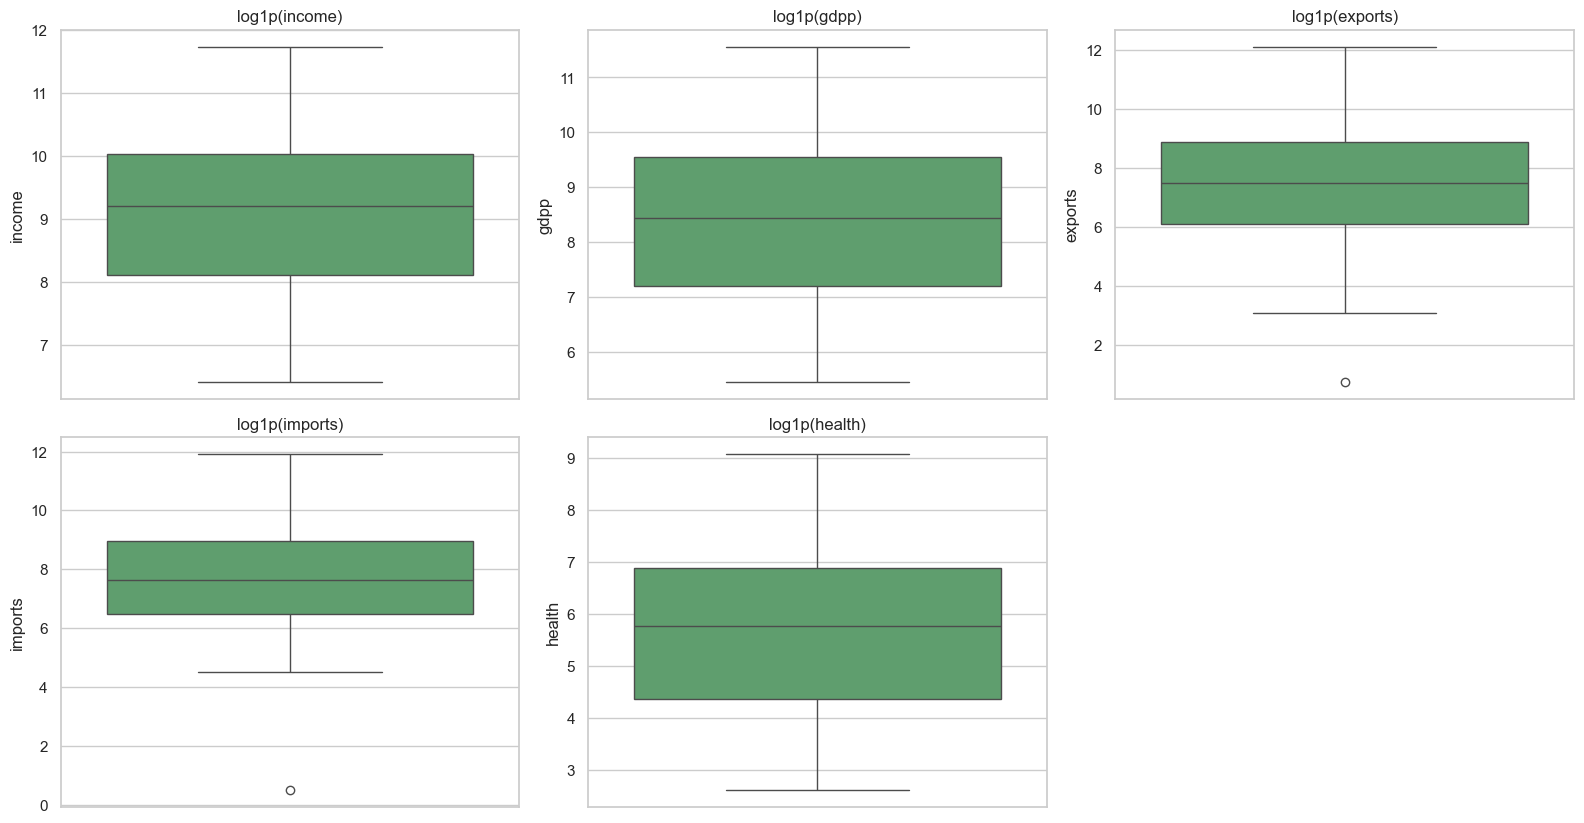

In [23]:
# Optional: log1p boxplots for skewed monetary features
if PLOT_LOG_BOXPLOTS:
    log_features = ["income", "gdpp", "exports", "imports", "health"]
    log_features = [c for c in log_features if c in feature_cols]

    df_log = np.log1p(df_prepared[log_features])

    n_features = len(log_features)
    ncols = 3
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(log_features):
        ax = axes[i]
        sns.boxplot(y=df_log[col], ax=ax, color="#55A868")
        ax.set_title(f"log1p({col})")
        ax.set_xlabel("")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


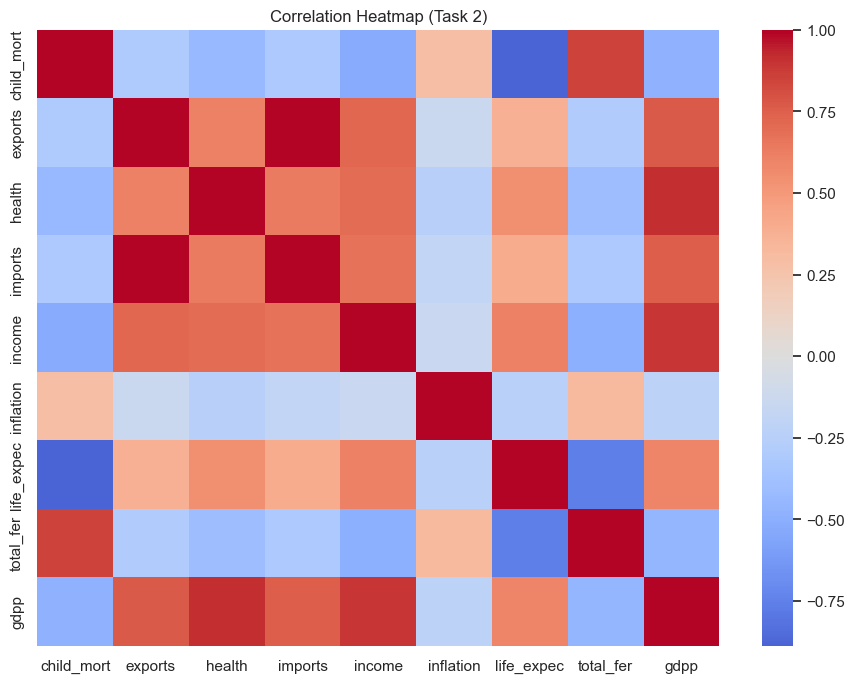


Correlations with child_mort (sorted):
life_expec   -0.886676
income       -0.524315
gdpp         -0.483032
health       -0.430438
imports      -0.319138
exports      -0.297230
inflation     0.288276
total_fer     0.848478
child_mort    1.000000
Name: child_mort, dtype: float64


In [24]:
# Correlation heatmap
corr = df_prepared[feature_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Task 2)")
plt.show()

# Quick context: how each variable relates to child_mort
if "child_mort" in feature_cols:
    print("\nCorrelations with child_mort (sorted):")
    print(corr["child_mort"].sort_values())


## Task 3 - Preprocessing for K-Means

K-Means relies on **Euclidean distance**, so features must be on comparable scales.

Before scaling, we use **IQR-based capping (winsorization)**. This is chosen because it reduces the leverage of extreme values without deleting countries.

After capping, we standardize all numeric features using `StandardScaler`.

In [25]:
# Winsorization / capping using the IQR bounds computed above
country = df_prepared[country_col].copy()

# df_model stores the winsorized (capped) numeric features used for clustering
df_model = df_prepared[feature_cols].copy()

for col in feature_cols:
    lower, upper = iqr_bounds[col]
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)

print("Winsorized (capped) feature preview:")
df_model.head()


Winsorized (capped) feature preview:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,55.30,41.9174,248.297,1610.0,9.44,56.2,5.82,553
1,16.6,1145.20,267.8950,1987.740,9930.0,4.49,76.3,1.65,4090
2,27.3,1712.64,185.9820,1400.440,12900.0,16.10,76.5,2.89,4460
3,119.0,2199.19,100.6050,1514.370,5900.0,22.40,60.1,6.16,3530
4,10.3,5551.00,735.6600,7185.800,19100.0,1.44,76.8,2.13,12200


## Standardization for K-Means

`StandardScaler` transforms each feature to have approximately **mean 0** and **standard deviation 1**.

This is required for Euclidean-distance methods like K-Means so that a single high-magnitude variable (for example, GDP per capita) does not dominate the clustering solution.


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# X_scaled is the standardized numeric feature matrix for clustering
X_scaled = scaler.fit_transform(df_model[feature_cols])

# df_scaled preserves the country column for interpretability
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df_model.index)
df_scaled.insert(0, country_col, country.values)

print("Scaled data preview:")
df_scaled.head()

# Validation: scaled numeric features should have mean ~ 0 and std ~ 1
scaled_means = df_scaled[feature_cols].mean().to_numpy()
# Use ddof=0 to match StandardScaler's variance definition
scaled_stds = df_scaled[feature_cols].std(ddof=0).to_numpy()

mean_ok = np.all(np.abs(scaled_means) < 1e-5)
std_ok = np.all(np.abs(scaled_stds - 1.0) < 1e-5)

print("\nScaled feature check:")
print("Mean (approx 0):", np.round(scaled_means, 6))
print("Std  (approx 1):", np.round(scaled_stds, 6))

if not (mean_ok and std_ok):
    raise AssertionError("Scaled features are not sufficiently close to mean=0 and std=1.")
else:
    print("Validation passed: scaled features are centered and standardized.")


Scaled data preview:

Scaled feature check:
Mean (approx 0): [-0. -0. -0. -0.  0. -0.  0.  0.  0.]
Std  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Validation passed: scaled features are centered and standardized.


### Outputs (in-memory only)

This notebook produces the following in-memory objects:

- `df_prepared`: raw data + percent-to-absolute conversion
- `df_model`: winsorized features (IQR capping) for clustering
- `X_scaled`: standardized numeric feature matrix
- `df_scaled`: standardized features with `country` preserved for interpretation

By default, `SAVE_OUTPUTS = False`, so no files are written to disk.

In [27]:
if SAVE_OUTPUTS:
    preprocessed_path = project_dir / "preprocessed_country_data.csv"
    scaled_path = project_dir / "scaled_features.csv"

    # Save only if explicitly requested
    df_prepared.to_csv(preprocessed_path, index=False)
    df_scaled.to_csv(scaled_path, index=False)

    print(f"Saved: {preprocessed_path.name} and {scaled_path.name}")
else:
    print("SAVE_OUTPUTS is False: no files were written.")


SAVE_OUTPUTS is False: no files were written.
